# Exercise 11.7: Bagging Two-Class Classification Models

This notebook implements the bagging experiment from Example 11.15:
- Create 5 random training-validation splits (2/3 train, 1/3 validation)
- For each split, perform naive cross-validation to select best polynomial model (degree 1-8)
- Compare misclassifications of individual models vs bagged model on entire dataset

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode
np.random.seed(0)  # For reproducibility

In [6]:
import autograd.numpy as np
import pandas as pd

datapath = './mlrefined_datasets/nonlinear_superlearn_datasets/'

In [7]:
# Load the data
csvname = datapath + 'new_circle_data.csv'
data = np.loadtxt(csvname, delimiter=',')
x = data[:-1, :]
y = data[-1:, :]
print(f'Feature shape: {np.shape(x)}')
print(f'Label shape: {np.shape(y)}')
print(f'Total number of samples: {x.shape[1]}')

Feature shape: (2, 99)
Label shape: (1, 99)
Total number of samples: 99


In [8]:
# Helper function: Create polynomial features
def create_poly_features(x, degree):
    """
    Create polynomial features up to given degree.
    For 2D input [x1, x2], creates features: 1, x1, x2, x1^2, x1*x2, x2^2, ...
    """
    N, P = x.shape
    features = [np.ones((1, P))]  # Start with bias term
    
    for d in range(1, degree + 1):
        for i in range(d + 1):
            j = d - i
            feature = (x[0, :]**i) * (x[1, :]**j)
            features.append(feature.reshape(1, -1))
    
    return np.vstack(features)

# Test with a simple example
x_test = np.array([[1, 2], [3, 4]]).T
poly_features = create_poly_features(x_test, 2)
print(f'Original features shape: {x_test.shape}')
print(f'Polynomial features (degree 2) shape: {poly_features.shape}')

Original features shape: (2, 2)
Polynomial features (degree 2) shape: (6, 2)


In [9]:
# Helper function: Softmax two-class classifier
def softmax_two_class(w, x):
    """
    Compute softmax two-class classification.
    Returns class predictions (+1 or -1).
    """
    # Compute raw output
    raw_output = np.dot(w.T, x)
    
    # For two-class softmax, we can use sigmoid
    prob_pos = 1.0 / (1.0 + np.exp(-raw_output))
    
    # Predict +1 if prob > 0.5, else -1
    predictions = np.where(prob_pos >= 0.5, 1, -1)
    
    return predictions

In [10]:
# Helper function: Softmax cost function
def softmax_cost(w, x, y):
    """
    Compute softmax cost for two-class classification.
    """
    # Convert labels to 0/1 format (from -1/+1)
    y_binary = (y + 1) / 2
    
    # Compute raw output
    raw_output = np.dot(w.T, x)
    
    # Compute log loss (binary cross-entropy)
    # Clip to avoid numerical issues
    prob_pos = 1.0 / (1.0 + np.exp(-np.clip(raw_output, -500, 500)))
    prob_pos = np.clip(prob_pos, 1e-10, 1 - 1e-10)
    
    cost = -np.mean(y_binary * np.log(prob_pos) + (1 - y_binary) * np.log(1 - prob_pos))
    
    return cost

In [11]:
# Helper function: Gradient descent for softmax
def gradient_descent_softmax(x, y, max_its, alpha):
    """
    Train softmax classifier using gradient descent.
    """
    # Convert labels to 0/1 format
    y_binary = (y + 1) / 2
    
    # Initialize weights
    w = np.random.randn(x.shape[0], 1) * 0.01
    
    # Gradient descent
    for it in range(max_its):
        # Compute predictions
        raw_output = np.dot(w.T, x)
        prob_pos = 1.0 / (1.0 + np.exp(-np.clip(raw_output, -500, 500)))
        
        # Compute gradient
        gradient = np.dot(x, (prob_pos - y_binary).T) / x.shape[1]
        
        # Update weights
        w = w - alpha * gradient
    
    return w

In [12]:
# Helper function: Count misclassifications
def count_misclassifications(w, x, y):
    """
    Count number of misclassifications.
    """
    predictions = softmax_two_class(w, x)
    misclass = np.sum(predictions.flatten() != y.flatten())
    return misclass

In [13]:
# Main function: Naive cross-validation to find best polynomial degree
def naive_cross_validation(x_train, y_train, x_val, y_val, max_degree=8):
    """
    Perform naive cross-validation to find the best polynomial degree.
    Returns the best degree and corresponding trained weights.
    """
    best_degree = 1
    best_cost = float('inf')
    best_weights = None
    
    # Training parameters
    max_its = 1000
    alpha = 0.1
    
    for degree in range(1, max_degree + 1):
        # Create polynomial features
        x_train_poly = create_poly_features(x_train, degree)
        x_val_poly = create_poly_features(x_val, degree)
        
        # Train model
        w = gradient_descent_softmax(x_train_poly, y_train, max_its, alpha)
        
        # Evaluate on validation set
        val_cost = softmax_cost(w, x_val_poly, y_val)
        
        # Update best model if this is better
        if val_cost < best_cost:
            best_cost = val_cost
            best_degree = degree
            best_weights = w
    
    return best_degree, best_weights

In [14]:
# Create 5 random training-validation splits
num_splits = 5
N_total = x.shape[1]
N_train = int(2 * N_total / 3)  # 2/3 for training

# Store results for each split
models = []  # List to store (degree, weights) for each split
train_indices_list = []
val_indices_list = []

print("Creating 5 random training-validation splits...")
print(f"Total samples: {N_total}")
print(f"Training samples per split: {N_train}")
print(f"Validation samples per split: {N_total - N_train}")
print()

Creating 5 random training-validation splits...
Total samples: 99
Training samples per split: 66
Validation samples per split: 33



In [15]:
# Perform cross-validation for each split
print("Performing naive cross-validation for each split...\n")

for split_idx in range(num_splits):
    # Create random split
    indices = np.random.permutation(N_total)
    train_indices = indices[:N_train]
    val_indices = indices[N_train:]
    
    train_indices_list.append(train_indices)
    val_indices_list.append(val_indices)
    
    # Split data
    x_train = x[:, train_indices]
    y_train = y[:, train_indices]
    x_val = x[:, val_indices]
    y_val = y[:, val_indices]
    
    # Perform naive cross-validation
    best_degree, best_weights = naive_cross_validation(x_train, y_train, x_val, y_val)
    
    # Store model
    models.append((best_degree, best_weights))
    
    print(f"Split {split_idx + 1}: Best polynomial degree = {best_degree}")

print("\nAll 5 models trained successfully!")

Performing naive cross-validation for each split...

Split 1: Best polynomial degree = 8
Split 2: Best polynomial degree = 5
Split 3: Best polynomial degree = 3
Split 4: Best polynomial degree = 8
Split 5: Best polynomial degree = 8

All 5 models trained successfully!


In [16]:
# Evaluate each individual model on the entire dataset
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print("\nIndividual Model Performance (on entire dataset):")
print("-" * 60)

individual_misclass = []

for split_idx, (degree, weights) in enumerate(models):
    # Create polynomial features for entire dataset
    x_poly = create_poly_features(x, degree)
    
    # Count misclassifications
    misclass = count_misclassifications(weights, x_poly, y)
    individual_misclass.append(misclass)
    
    print(f"Model {split_idx + 1} (degree {degree}): {misclass} misclassifications")

print(f"\nAverage misclassifications across individual models: {np.mean(individual_misclass):.2f}")


EVALUATION RESULTS

Individual Model Performance (on entire dataset):
------------------------------------------------------------
Model 1 (degree 8): 23 misclassifications
Model 2 (degree 5): 11 misclassifications
Model 3 (degree 3): 16 misclassifications
Model 4 (degree 8): 23 misclassifications
Model 5 (degree 8): 21 misclassifications

Average misclassifications across individual models: 18.80


In [17]:
# Create bagged model using mode (most popular prediction)
print("\n" + "-" * 60)
print("Bagged Model Performance (on entire dataset):")
print("-" * 60)

# Collect predictions from all models
all_predictions = []

for degree, weights in models:
    # Create polynomial features
    x_poly = create_poly_features(x, degree)
    
    # Get predictions
    predictions = softmax_two_class(weights, x_poly)
    all_predictions.append(predictions.flatten())

# Stack predictions
all_predictions = np.array(all_predictions)  # Shape: (5, N_total)

# Compute mode (most popular prediction) for each sample
bagged_predictions = []
for i in range(N_total):
    sample_predictions = all_predictions[:, i]
    # Count +1 and -1
    count_pos = np.sum(sample_predictions == 1)
    count_neg = np.sum(sample_predictions == -1)
    # Mode is the most frequent
    mode_pred = 1 if count_pos > count_neg else -1
    bagged_predictions.append(mode_pred)

bagged_predictions = np.array(bagged_predictions)

# Count misclassifications
bagged_misclass = np.sum(bagged_predictions != y.flatten())

print(f"Bagged model: {bagged_misclass} misclassifications")
print("\n" + "="*60)


------------------------------------------------------------
Bagged Model Performance (on entire dataset):
------------------------------------------------------------
Bagged model: 21 misclassifications



In [18]:
# Summary comparison
print("\nSUMMARY COMPARISON")
print("="*60)
print(f"Total samples in dataset: {N_total}")
print("\nMisclassifications on entire dataset:")
for i, misclass in enumerate(individual_misclass):
    degree = models[i][0]
    print(f"  Model {i+1} (degree {degree}): {misclass}")
print(f"\n  Average across individual models: {np.mean(individual_misclass):.2f}")
print(f"  Bagged model: {bagged_misclass}")
print(f"\nImprovement: {np.mean(individual_misclass) - bagged_misclass:.2f} fewer misclassifications")
print("="*60)


SUMMARY COMPARISON
Total samples in dataset: 99

Misclassifications on entire dataset:
  Model 1 (degree 8): 23
  Model 2 (degree 5): 11
  Model 3 (degree 3): 16
  Model 4 (degree 8): 23
  Model 5 (degree 8): 21

  Average across individual models: 18.80
  Bagged model: 21

Improvement: -2.20 fewer misclassifications


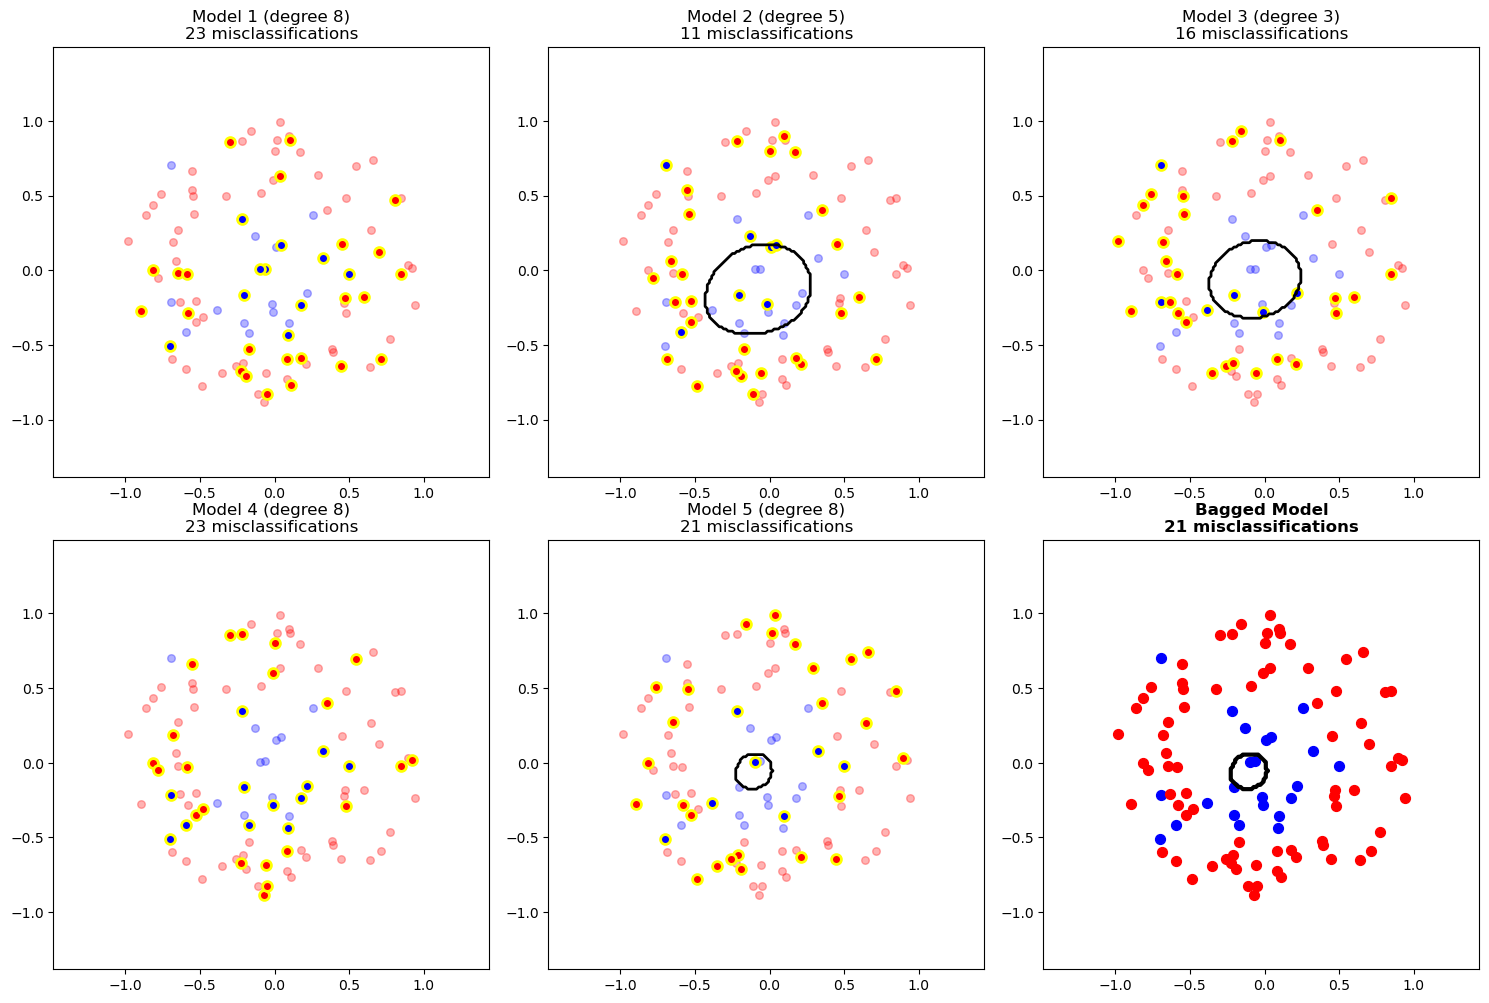


Visualization saved to bagging_results.png


In [20]:
# Visualization: Plot the data and decision boundaries
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Create a grid for plotting decision boundaries
x1_min, x1_max = x[0, :].min() - 0.5, x[0, :].max() + 0.5
x2_min, x2_max = x[1, :].min() - 0.5, x[1, :].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                        np.linspace(x2_min, x2_max, 200))
grid_points = np.c_[xx1.ravel(), xx2.ravel()].T

# Plot each individual model
for split_idx, (degree, weights) in enumerate(models):
    ax = axes[split_idx]
    
    # Get validation indices for this split
    val_indices = val_indices_list[split_idx]
    
    # Create polynomial features for grid
    grid_poly = create_poly_features(grid_points, degree)
    
    # Get predictions
    Z = softmax_two_class(weights, grid_poly)
    Z = Z.reshape(xx1.shape)
    
    # Plot decision boundary
    ax.contour(xx1, xx2, Z, levels=[0], colors='black', linewidths=2)
    
    # Plot training data (faded)
    train_indices = train_indices_list[split_idx]
    x_train = x[:, train_indices]
    y_train = y[:, train_indices]
    ax.scatter(x_train[0, y_train[0]==1], x_train[1, y_train[0]==1], 
              c='blue', marker='o', alpha=0.3, s=30)
    ax.scatter(x_train[0, y_train[0]==-1], x_train[1, y_train[0]==-1], 
              c='red', marker='o', alpha=0.3, s=30)
    
    # Plot validation data (highlighted)
    x_val = x[:, val_indices]
    y_val = y[:, val_indices]
    ax.scatter(x_val[0, y_val[0]==1], x_val[1, y_val[0]==1], 
              c='blue', marker='o', edgecolors='yellow', linewidths=2, s=50)
    ax.scatter(x_val[0, y_val[0]==-1], x_val[1, y_val[0]==-1], 
              c='red', marker='o', edgecolors='yellow', linewidths=2, s=50)
    
    ax.set_title(f'Model {split_idx+1} (degree {degree})\n{individual_misclass[split_idx]} misclassifications')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_aspect('equal')

# Plot bagged model
ax = axes[5]

# Get bagged predictions for grid
grid_predictions_all = []
for degree, weights in models:
    grid_poly = create_poly_features(grid_points, degree)
    grid_pred = softmax_two_class(weights, grid_poly)
    grid_predictions_all.append(grid_pred.flatten())

grid_predictions_all = np.array(grid_predictions_all)
bagged_grid = []
for i in range(grid_points.shape[1]):
    sample_preds = grid_predictions_all[:, i]
    count_pos = np.sum(sample_preds == 1)
    count_neg = np.sum(sample_preds == -1)
    mode_pred = 1 if count_pos > count_neg else -1
    bagged_grid.append(mode_pred)

bagged_grid = np.array(bagged_grid).reshape(xx1.shape)

# Plot decision boundary
ax.contour(xx1, xx2, bagged_grid, levels=[0], colors='black', linewidths=3)

# Plot all data
ax.scatter(x[0, y[0]==1], x[1, y[0]==1], c='blue', marker='o', s=50)
ax.scatter(x[0, y[0]==-1], x[1, y[0]==-1], c='red', marker='o', s=50)

ax.set_title(f'Bagged Model\n{bagged_misclass} misclassifications', fontweight='bold')
ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\nVisualization saved to bagging_results.png")